# 🎭 Comparing Means — The Non-Parametric Understudies
### Stage 4: Mann-Whitney U, Wilcoxon Signed-Rank & Kruskal-Wallis  |  ⏱️ ~40-minute session

---

**Recap:** In Stage 3 you learned t-tests and ANOVA — but they all lean on one big assumption: **the data is roughly normally distributed** (checked via Shapiro-Wilk in Stage 2). What happens when that assumption fails? Small sample, skewed data, outliers, ordinal ratings (like a 1–5 satisfaction score)...

That's exactly what today's three tests are for. Think of them as **understudies** — every parametric test has a non-parametric alternative standing right behind it, ready to step in when normality breaks down. They work on **ranks** instead of raw values, which makes them robust to skew and outliers, at the cost of a little statistical power.

### The direct mapping (memorize this!)

| Parametric test (Stage 3) | Non-parametric alternative (today) | Compares |
|---|---|---|
| Independent samples t-test | **Mann-Whitney U Test** | 2 unrelated groups |
| Paired samples t-test | **Wilcoxon Signed-Rank Test** | Same subjects, 2 time points |
| One-way ANOVA | **Kruskal-Wallis Test** | 3+ unrelated groups |

### Session map (suggested pacing)

| Time | Topic |
|---|---|
| 0:00 – 0:12 | Mann-Whitney U Test |
| 0:12 – 0:24 | Wilcoxon Signed-Rank Test |
| 0:24 – 0:36 | Kruskal-Wallis Test |
| 0:36 – 0:40 | Bonus: Dunn's post-hoc test |

We'll reuse `tips` and `penguins` so you can directly compare today's results against Stage 3's t-test/ANOVA output on the *same* data.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (7, 4)
sns.set_style("whitegrid")

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins").dropna()

print(tips.shape, penguins.shape)
tips.head()


(244, 7) (333, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1️⃣ Mann-Whitney U Test — "Do two unrelated groups differ?" (no normality needed)

### Theory

The Mann-Whitney U test (also called the **Wilcoxon rank-sum test**) is the go-to replacement for the independent samples t-test when your data isn't normal.

**How it works, conceptually:**
1. Pool both groups together and **rank** every value from smallest to largest (ignoring which group it came from).
2. Sum the ranks for each group.
3. If one group tends to have consistently higher ranks than the other, that's evidence of a real difference.

- **H₀:** The two groups come from the same distribution (neither tends to have systematically larger values).
- **H₁:** One group tends to have systematically larger values than the other.

> 💡 Subtle but important: Mann-Whitney tests whether one distribution is **stochastically greater** than the other — it's about overall distribution/rank, not strictly "medians," though it's commonly described that way as a simplification.

### Scenario
In Stage 3, we compared `total_bill` between smokers and non-smokers with an independent t-test. Let's check: was that even the right call? Then run Mann-Whitney U alongside it.


In [2]:
smoker_bills = tips.loc[tips['smoker'] == 'Yes', 'total_bill']
nonsmoker_bills = tips.loc[tips['smoker'] == 'No', 'total_bill']

# Sanity check: is total_bill actually normal within each group? (Stage 2 skill)
print("Shapiro-Wilk (Smoker):", stats.shapiro(smoker_bills))
print("Shapiro-Wilk (Non-Smoker):", stats.shapiro(nonsmoker_bills))


Shapiro-Wilk (Smoker): ShapiroResult(statistic=np.float64(0.9367441211736873), pvalue=np.float64(0.0002166644188825324))
Shapiro-Wilk (Non-Smoker): ShapiroResult(statistic=np.float64(0.9045338652021683), pvalue=np.float64(2.2108584744714854e-08))


Both come back with low p-values (non-normal — remember total_bill is right-skewed, as we saw back in Stage 2). This is a textbook case for Mann-Whitney U instead of the t-test.


In [3]:
u_stat, p_value = stats.mannwhitneyu(smoker_bills, nonsmoker_bills, alternative='two-sided')

print(f"U-statistic: {u_stat:.2f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> Smokers and non-smokers have significantly different bill distributions")
else:
    print("Verdict: Fail to reject H0 -> No significant difference detected")

print(f"\nMedian bill (Smoker): {smoker_bills.median():.2f}")
print(f"Median bill (Non-Smoker): {nonsmoker_bills.median():.2f}")


U-statistic: 7531.50
p-value: 0.341334
Verdict: Fail to reject H0 -> No significant difference detected

Median bill (Smoker): 17.92
Median bill (Non-Smoker): 17.59


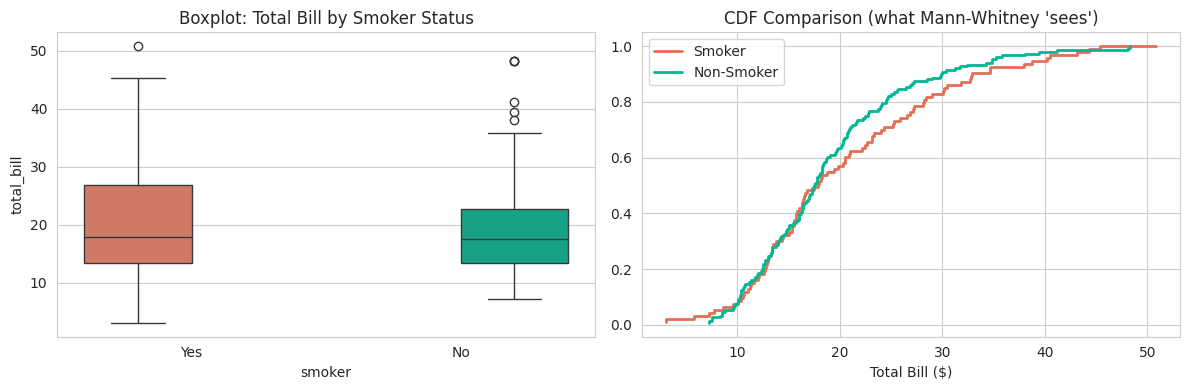

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=tips, x='smoker', y='total_bill', hue='smoker',
            palette=['#e17055', '#00b894'], ax=axes[0], legend=False)
axes[0].set_title("Boxplot: Total Bill by Smoker Status")

for data, label, color in [(smoker_bills, 'Smoker', '#e17055'), (nonsmoker_bills, 'Non-Smoker', '#00b894')]:
    sorted_data = np.sort(data)
    ranks_cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    axes[1].step(sorted_data, ranks_cdf, label=label, color=color, linewidth=2)
axes[1].set_title("CDF Comparison (what Mann-Whitney 'sees')")
axes[1].set_xlabel("Total Bill ($)")
axes[1].legend()

plt.tight_layout()
plt.show()


### 🎯 60-second challenge
Compare `tip` between Male and Female customers using Mann-Whitney U. Does the conclusion match what the independent t-test told you back in Stage 3?


In [5]:
male_tip = tips.loc[tips['sex'] == 'Male', 'tip']
female_tip = tips.loc[tips['sex'] == 'Female', 'tip']

u_stat, p_value = stats.mannwhitneyu(male_tip, female_tip, alternative='two-sided')
print(f"U={u_stat:.2f}, p={p_value:.6f}")


U=7289.50, p=0.383354


## 2️⃣ Wilcoxon Signed-Rank Test — "Did the SAME subjects change?" (no normality needed)

### Theory

This is the non-parametric replacement for the **paired** t-test. Just like the paired t-test, it needs the same subjects measured twice — but instead of assuming the *differences* are normally distributed, it only uses their **signs and ranks**.

**How it works, conceptually:**
1. Compute the difference for every pair (after − before).
2. Rank the *absolute* differences (ignore zeros).
3. Sum the ranks separately for positive and negative differences.
4. If positive and negative ranks are wildly unbalanced, that's evidence of a real, consistent shift.

- **H₀:** The median difference between pairs is zero (no real change).
- **H₁:** The median difference is non-zero.

### Scenario
Let's revisit our weight-loss program from Stage 3 — but this time, simulate a **messier, skewed** real-world version (a few participants barely change, a few drop a lot of weight, one even gains slightly). This kind of lopsided data is exactly when Wilcoxon is safer than a paired t-test.


In [6]:
np.random.seed(7)
n = 18
before = np.random.normal(loc=85, scale=10, size=n)

# Skewed, messy change: mostly loses weight, a long tail of bigger losses, one small gain
change = -np.random.exponential(scale=2.5, size=n) + 0.5
after = before + change

weight_df = pd.DataFrame({'participant': range(1, n+1), 'before': before, 'after': after})
weight_df['difference'] = weight_df['after'] - weight_df['before']
weight_df.head()


,participant,before,after,difference
0,1,101.905257,101.750862,-0.154395
1,2,80.340626,78.852732,-1.487894
2,3,85.328202,79.832433,-5.495769
3,4,89.075163,89.217883,0.142721
4,5,77.110770,75.758009,-1.352760


In [7]:
# Check normality of the DIFFERENCES -- this is what the paired t-test actually assumes
diff_stat, diff_p = stats.shapiro(weight_df['difference'])
print(f"Shapiro-Wilk on differences: W={diff_stat:.4f}, p={diff_p:.6f}")
print("-> Differences are skewed/non-normal, so Wilcoxon is the safer choice here.")


Shapiro-Wilk on differences: W=0.8785, p=0.024637
-> Differences are skewed/non-normal, so Wilcoxon is the safer choice here.


In [8]:
w_stat, p_value = stats.wilcoxon(weight_df['before'], weight_df['after'])

print(f"Wilcoxon statistic: {w_stat:.2f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> The program caused a statistically significant change in weight")
else:
    print("Verdict: Fail to reject H0 -> No significant change detected")

print(f"\nMedian difference: {weight_df['difference'].median():.2f} kg")


Wilcoxon statistic: 2.00
p-value: 0.000023
Verdict: Reject H0 -> The program caused a statistically significant change in weight

Median difference: -1.15 kg


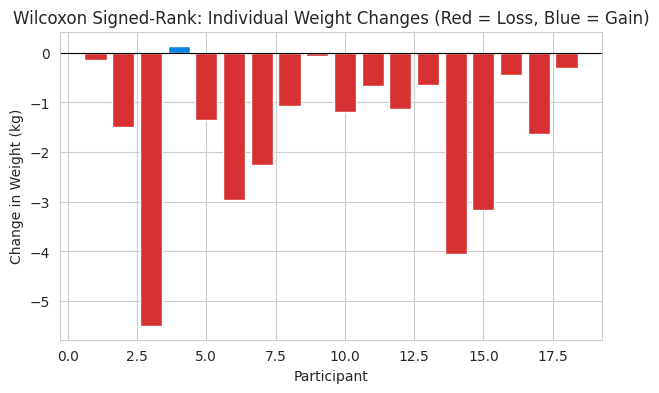

In [9]:
fig, ax = plt.subplots()
colors = ['#d63031' if d < 0 else '#0984e3' for d in weight_df['difference']]
ax.bar(weight_df['participant'], weight_df['difference'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("Participant")
ax.set_ylabel("Change in Weight (kg)")
ax.set_title("Wilcoxon Signed-Rank: Individual Weight Changes (Red = Loss, Blue = Gain)")
plt.show()


**Compare to Stage 3:** the paired t-test assumed the differences were normal. Here we deliberately built skewed, messy differences — a single outlier or lopsided tail like this can distort a t-test's p-value, while Wilcoxon (working on ranks) handles it gracefully.


## 3️⃣ Kruskal-Wallis Test — "Do 3+ unrelated groups differ?" (no normality needed)

### Theory

The non-parametric sibling of one-way ANOVA. Instead of comparing group means directly, it **ranks all observations across all groups combined**, then checks whether the average rank differs meaningfully between groups.

$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)$$

where $R_i$ is the sum of ranks for group *i*.

- **H₀:** All groups come from the same distribution (equal medians/ranks).
- **H₁:** At least one group differs.

Just like ANOVA, **Kruskal-Wallis only tells you that a difference exists somewhere** — not which specific pairs differ. For that, we need a post-hoc test (bonus section below).

### Scenario
Let's test `bill_depth_mm` across the 3 penguin species — a variable worth double-checking for normality before trusting ANOVA blindly.


In [10]:
adelie = penguins.loc[penguins['species'] == 'Adelie', 'bill_depth_mm']
chinstrap = penguins.loc[penguins['species'] == 'Chinstrap', 'bill_depth_mm']
gentoo = penguins.loc[penguins['species'] == 'Gentoo', 'bill_depth_mm']

for name, group in [('Adelie', adelie), ('Chinstrap', chinstrap), ('Gentoo', gentoo)]:
    stat, p = stats.shapiro(group)
    print(f"{name}: Shapiro-Wilk p={p:.4f}")


Adelie: Shapiro-Wilk p=0.1047
Chinstrap: Shapiro-Wilk p=0.1418
Gentoo: Shapiro-Wilk p=0.0438


In [11]:
h_stat, p_value = stats.kruskal(adelie, chinstrap, gentoo)

print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_value:.6e}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> At least one species has a significantly different bill depth")
else:
    print("Verdict: Fail to reject H0 -> No significant difference across species")


H-statistic: 217.5578
p-value: 5.727002e-48
Verdict: Reject H0 -> At least one species has a significantly different bill depth


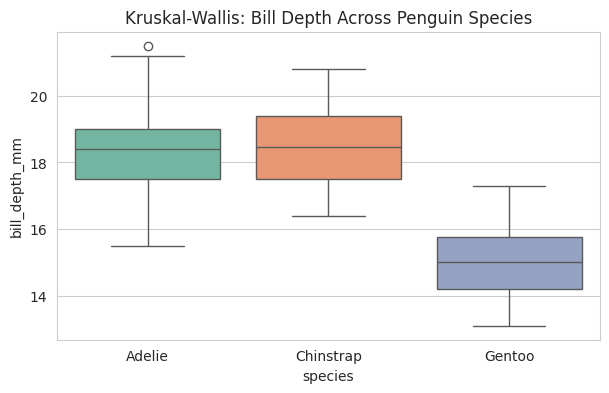

In [12]:
fig, ax = plt.subplots()
sns.boxplot(data=penguins, x='species', y='bill_depth_mm', hue='species',
            palette='Set2', ax=ax, legend=False)
ax.set_title("Kruskal-Wallis: Bill Depth Across Penguin Species")
plt.show()


### 🎯 60-second challenge
Run Kruskal-Wallis on `flipper_length_mm` across the 3 species. Compare the conclusion to what one-way ANOVA told you in Stage 3 for `body_mass_g` — do non-parametric and parametric routes usually agree when data is reasonably well-behaved?


In [13]:
a_f = penguins.loc[penguins['species'] == 'Adelie', 'flipper_length_mm']
c_f = penguins.loc[penguins['species'] == 'Chinstrap', 'flipper_length_mm']
g_f = penguins.loc[penguins['species'] == 'Gentoo', 'flipper_length_mm']

h_stat, p_value = stats.kruskal(a_f, c_f, g_f)
print(f"H={h_stat:.4f}, p={p_value:.6e}")


H=237.3457, p=2.890851e-52


## 4️⃣ Bonus: Dunn's Test — the Tukey HSD of the non-parametric world

### Theory

Just like Tukey HSD follows a significant ANOVA, **Dunn's test** follows a significant Kruskal-Wallis result to find out *which specific pairs* of groups differ — while correcting for multiple comparisons (we'll use the common Bonferroni correction).


In [14]:
import scikit_posthocs as sp

dunn_result = sp.posthoc_dunn(
    [adelie.values, chinstrap.values, gentoo.values],
    p_adjust='bonferroni'
)
dunn_result.columns = ['Adelie', 'Chinstrap', 'Gentoo']
dunn_result.index = ['Adelie', 'Chinstrap', 'Gentoo']
dunn_result.round(4)


,Adelie,Chinstrap,Gentoo
Adelie,1.0,1.0,0.0
Chinstrap,1.0,1.0,0.0
Gentoo,0.0,0.0,1.0


**How to read this:** each cell is the adjusted p-value for that pair of species. Any value below 0.05 means that pair's bill depth distributions differ significantly — same interpretation logic as the Tukey HSD table from Stage 3, just built on ranks instead of means.


## 📋 Cheat Sheet — Stage 4 Recap

| Test | Non-parametric replacement for | Groups | H₀ |
|---|---|---|---|
| **Mann-Whitney U** | Independent samples t-test | 2 unrelated | Same distribution / no rank shift |
| **Wilcoxon Signed-Rank** | Paired samples t-test | 2 related (same subjects) | Median difference = 0 |
| **Kruskal-Wallis** | One-way ANOVA | 3+ unrelated | All groups same distribution |
| **Dunn's Test** | Tukey HSD | Post-hoc pairs after Kruskal-Wallis | Specific pair medians equal |

### The decision rule, one more time
1. Check normality (Shapiro-Wilk, Stage 2).
2. Normal → use the Stage 3 parametric test.
3. Not normal (or small/skewed/ordinal data) → use today's non-parametric counterpart.
4. If comparing 3+ groups and the omnibus test is significant → run the matching post-hoc test (Tukey HSD or Dunn's) to find *which* pairs differ.

**Where we go next:** Stage 5 moves from comparing means/medians to comparing **categorical** data — the Chi-Square test.
